# Laboratorio 9 - Redes Neuronales Artificiales
## Avances (Pasaporte)

A continuación se presentan los avances correspondientes a la primera fase del laboratorio. El objetivo es crear modelos de clasificación utilizando Redes Neuronales Artificiales (RNA) para predecir la categoría de precio de las propiedades de Airbnb.

### 1 y 2. Preparación de datos y Variable de Respuesta
Para mantener la coherencia y poder hacer comparaciones válidas más adelante, estamos utilizando exactamente los mismos conjuntos de entrenamiento y prueba que en la entrega anterior (Regresión Logística). La variable respuesta a utilizar es `price_cat`, la cual categoriza los precios en 'barata', 'media' y 'cara'.

In [4]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import time

# Cargar los datos del RData
result = pyreadr.read_r("listings.RData")
data = result['listings']

# Limpieza básica del precio para categorizarlo
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

# Discretizamos la variable respuesta en 3 categorías balanceadas
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

# Seleccionamos las mismas variables predictoras del lab anterior
X = data[['accommodates', 'bathrooms', 'bedrooms', 'beds',
          'minimum_nights', 'number_of_reviews', 'review_scores_rating']]

X = X.dropna()
y = data['price_cat'][X.index]

# Partición 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Instancias para entrenamiento: {X_train.shape[0]}")
print(f"Instancias para prueba: {X_test.shape[0]}")


Instancias para entrenamiento: 43905
Instancias para prueba: 18817


C:\Users\jplop\AppData\Local\Temp\ipykernel_30448\858524940.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])


### 3, 4 y 5. Entrenamiento y Evaluación: Modelo 1
Para el primer modelo, hemos decidido probar una red neuronal profunda pero no excesivamente compleja. Utilizaremos dos capas ocultas de 10 neuronas cada una y la función de activación ReLU, que suele ser bastante eficiente y rápida de entrenar.

In [5]:
# Modelo 1: Topología (10, 10), Activación: ReLU
mlp1 = MLPClassifier(hidden_layer_sizes=(10, 10), activation='relu', max_iter=500, random_state=42)

start_time = time.time()
mlp1.fit(X_train, y_train)
time1 = time.time() - start_time

y_pred1 = mlp1.predict(X_test)
y_train_pred1 = mlp1.predict(X_train)

# Matriz de confusión
cm1 = confusion_matrix(y_test, y_pred1, labels=['barata', 'media', 'cara'])
print("Matriz de confusión Modelo 1:")
display(pd.DataFrame(cm1, index=['Real barata', 'Real media', 'Real cara'], columns=['Pred barata', 'Pred media', 'Pred cara']))
print("\nReporte de Clasificación Modelo 1:")
print(classification_report(y_test, y_pred1))


Matriz de confusión Modelo 1:


,Pred barata,Pred media,Pred cara
Real barata,4330,1983,375
Real media,1667,3232,1465
Real cara,449,1555,3761



Reporte de Clasificación Modelo 1:
              precision    recall  f1-score   support

      barata       0.67      0.65      0.66      6688
        cara       0.67      0.65      0.66      5765
       media       0.48      0.51      0.49      6364

    accuracy                           0.60     18817
   macro avg       0.61      0.60      0.60     18817
weighted avg       0.61      0.60      0.60     18817



### 3, 4 y 5. Entrenamiento y Evaluación: Modelo 2
Como contraste, el segundo modelo será más "ancho" pero menos profundo: una sola capa oculta de 20 neuronas. Además, usaremos la función de activación `tanh` para ver cómo se comporta con valores escalados entre -1 y 1.

In [6]:
# Modelo 2: Topología (20,), Activación: Tanh
mlp2 = MLPClassifier(hidden_layer_sizes=(20,), activation='tanh', max_iter=500, random_state=42)

start_time = time.time()
mlp2.fit(X_train, y_train)
time2 = time.time() - start_time

y_pred2 = mlp2.predict(X_test)
y_train_pred2 = mlp2.predict(X_train)

# Matriz de confusión
cm2 = confusion_matrix(y_test, y_pred2, labels=['barata', 'media', 'cara'])
print("Matriz de confusión Modelo 2:")
display(pd.DataFrame(cm2, index=['Real barata', 'Real media', 'Real cara'], columns=['Pred barata', 'Pred media', 'Pred cara']))
print("\nReporte de Clasificación Modelo 2:")
print(classification_report(y_test, y_pred2))


Matriz de confusión Modelo 2:


,Pred barata,Pred media,Pred cara
Real barata,4455,1817,416
Real media,1773,3032,1559
Real cara,476,1412,3877



Reporte de Clasificación Modelo 2:
              precision    recall  f1-score   support

      barata       0.66      0.67      0.67      6688
        cara       0.66      0.67      0.67      5765
       media       0.48      0.48      0.48      6364

    accuracy                           0.60     18817
   macro avg       0.60      0.61      0.60     18817
weighted avg       0.60      0.60      0.60     18817



### 6. Comparación y Análisis de Equivocaciones
A continuación, comparamos ambos modelos analizando no solo la precisión global, sino el tiempo que les tomó converger y los tipos de errores que cometieron.

In [7]:
acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)

print("--- RENDIMIENTO GLOBAL ---")
print(f"Modelo 1 (ReLU, 10x10): Tiempo = {time1:.2f}s | Accuracy = {acc1:.4f}")
print(f"Modelo 2 (Tanh, 20): Tiempo = {time2:.2f}s | Accuracy = {acc2:.4f}\n")

if acc1 > acc2:
    best_model = mlp1
else:
    best_model = mlp2
    
print("--- ANÁLISIS DE EQUIVOCACIONES EN MATRICES DE CONFUSIÓN ---")
print("1. Donde más se equivocaron los modelos:")
print("   Al observar ambas matrices de confusión, notamos que el mayor número de errores se da en la categoría 'media'.")
print("   Muchos listados de precio medio son clasificados como baratos o caros. Esto es esperable ya que las características")
print("   de un Airbnb de precio medio se traslapan con los extremos.")
print("\n2. Donde menos se equivocaron:")
print("   Afortunadamente, los errores extremos son los menos frecuentes. Es decir, predecir que un Airbnb es 'caro' cuando")
print("   en realidad es 'barato' (o viceversa) ocurre muchas menos veces (ej. alrededor de 300-400 casos).")
print("\n3. Importancia de los errores:")
print("   Para una empresa como SmartStay, los errores graves (confundir caro con barato) son los más costosos, ya que")
print("   proponer una propiedad de bajo presupuesto a un cliente premium arruinaría la experiencia, o viceversa.")
print("   Como la red neuronal comete muy pocos de estos errores graves, se considera un modelo aceptable para el negocio,")
print("   a pesar de que el 'accuracy' global ronde el 60%.")


--- RENDIMIENTO GLOBAL ---
Modelo 1 (ReLU, 10x10): Tiempo = 4.57s | Accuracy = 0.6017
Modelo 2 (Tanh, 20): Tiempo = 5.85s | Accuracy = 0.6039

--- ANÁLISIS DE EQUIVOCACIONES EN MATRICES DE CONFUSIÓN ---
1. Donde más se equivocaron los modelos:
   Al observar ambas matrices de confusión, notamos que el mayor número de errores se da en la categoría 'media'.
   Muchos listados de precio medio son clasificados como baratos o caros. Esto es esperable ya que las características
   de un Airbnb de precio medio se traslapan con los extremos.

2. Donde menos se equivocaron:
   Afortunadamente, los errores extremos son los menos frecuentes. Es decir, predecir que un Airbnb es 'caro' cuando
   en realidad es 'barato' (o viceversa) ocurre muchas menos veces (ej. alrededor de 300-400 casos).

3. Importancia de los errores:
   Para una empresa como SmartStay, los errores graves (confundir caro con barato) son los más costosos, ya que
   proponer una propiedad de bajo presupuesto a un cliente premium

### 7. Análisis de Sobreajuste (Overfitting)
Evaluamos si el modelo está memorizando los datos de entrenamiento comparando sus resultados con datos que nunca ha visto (el conjunto de prueba).

In [8]:
acc_train1 = accuracy_score(y_train, y_train_pred1)
acc_train2 = accuracy_score(y_train, y_train_pred2)

print("Comparación de Accuracy (Train vs Test):")
print(f"Modelo 1: Train = {acc_train1:.4f} | Test = {acc1:.4f} | Diferencia = {abs(acc_train1-acc1):.4f}")
print(f"Modelo 2: Train = {acc_train2:.4f} | Test = {acc2:.4f} | Diferencia = {abs(acc_train2-acc2):.4f}")

print("\nInterpretación:")
print("Las diferencias entre el rendimiento con datos de entrenamiento y datos de prueba son sumamente bajas en ambos modelos.")
print("Esto nos indica que los modelos no están sobreajustados (overfitting). Han logrado generalizar los patrones de los datos,")
print("y su rendimiento, aunque no es perfecto, es consistente independientemente de los datos que se le presenten.")


Comparación de Accuracy (Train vs Test):
Modelo 1: Train = 0.5980 | Test = 0.6017 | Diferencia = 0.0037
Modelo 2: Train = 0.6039 | Test = 0.6039 | Diferencia = 0.0000

Interpretación:
Las diferencias entre el rendimiento con datos de entrenamiento y datos de prueba son sumamente bajas en ambos modelos.
Esto nos indica que los modelos no están sobreajustados (overfitting). Han logrado generalizar los patrones de los datos,
y su rendimiento, aunque no es perfecto, es consistente independientemente de los datos que se le presenten.


### 8. Optimización (Tuning) del Modelo Elegido
Tomando el mejor modelo de la prueba anterior, realizamos un ajuste manual de parámetros (tasa de aprendizaje y regularización alpha) para discutir si se puede mejorar su capacidad predictiva.

In [9]:
best_hidden = best_model.hidden_layer_sizes
best_act = best_model.activation

# Incrementamos alpha para una mayor penalización (regularización) y ajustamos la tasa de aprendizaje
mlp_tuned = MLPClassifier(
    hidden_layer_sizes=best_hidden, 
    activation=best_act, 
    alpha=0.1, 
    learning_rate_init=0.001, 
    max_iter=1000, 
    random_state=42
)

start_time = time.time()
mlp_tuned.fit(X_train, y_train)
time_tuned = time.time() - start_time

y_pred_tuned = mlp_tuned.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
acc_train_tuned = accuracy_score(y_train, mlp_tuned.predict(X_train))

print(f"Modelo Tuneado:")
print(f"- Accuracy Train: {acc_train_tuned:.4f}")
print(f"- Accuracy Test: {acc_tuned:.4f}")
print(f"- Diferencia: {abs(acc_train_tuned - acc_tuned):.4f}")

print("\nDiscusión sobre la mejora del modelo:")
print("Tras ajustar la regularización (alpha=0.1) e incrementar las iteraciones máximas, observamos que")
print("el modelo mantiene un accuracy bastante similar al original (apenas hay un cambio decimal).")
print("Dado que ya confirmamos en el paso 7 que el modelo original NO tenía sobreajuste, es lógico que agregar")
print("más regularización no mejore drásticamente el modelo, puesto que el problema no era de varianza (overfitting),")
print("sino más bien que el límite predictivo de estas variables ronda el 60-61%. Para mejorar significativamente,")
print("necesitaríamos agregar nuevas variables al dataset o realizar ingeniería de características (feature engineering).")


Modelo Tuneado:
- Accuracy Train: 0.6045
- Accuracy Test: 0.6051
- Diferencia: 0.0006

Discusión sobre la mejora del modelo:
Tras ajustar la regularización (alpha=0.1) e incrementar las iteraciones máximas, observamos que
el modelo mantiene un accuracy bastante similar al original (apenas hay un cambio decimal).
Dado que ya confirmamos en el paso 7 que el modelo original NO tenía sobreajuste, es lógico que agregar
más regularización no mejore drásticamente el modelo, puesto que el problema no era de varianza (overfitting),
sino más bien que el límite predictivo de estas variables ronda el 60-61%. Para mejorar significativamente,
necesitaríamos agregar nuevas variables al dataset o realizar ingeniería de características (feature engineering).


### 9 y 10. Modelos de Regresión con Redes Neuronales


In [10]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Variable respuesta numérica
y_reg = data['price'][X.index]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.3, random_state=42
)

# Escalado 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_r)
X_test_s  = scaler.transform(X_test_r)

# Modelo R1
mlp_r1 = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu',
                      max_iter=500, random_state=42)
start = time.time()
mlp_r1.fit(X_train_s, y_train_r)
time_r1 = time.time() - start

pred_r1_test  = mlp_r1.predict(X_test_s)
pred_r1_train = mlp_r1.predict(X_train_s)

rmse_r1  = np.sqrt(mean_squared_error(y_test_r, pred_r1_test))
mae_r1   = mean_absolute_error(y_test_r, pred_r1_test)
r2_r1    = r2_score(y_test_r, pred_r1_test)

print('Modelo R1 (100-50, ReLU):')
print(f'  RMSE  = {rmse_r1:.4f}')
print(f'  MAE   = {mae_r1:.4f}')
print(f'  R2    = {r2_r1:.4f}')
print(f'  Tiempo = {time_r1:.2f}s')

# Modelo R2
mlp_r2 = MLPRegressor(hidden_layer_sizes=(200,), activation='tanh',
                      max_iter=500, random_state=42)
start = time.time()
mlp_r2.fit(X_train_s, y_train_r)
time_r2 = time.time() - start

pred_r2_test  = mlp_r2.predict(X_test_s)
pred_r2_train = mlp_r2.predict(X_train_s)

rmse_r2  = np.sqrt(mean_squared_error(y_test_r, pred_r2_test))
mae_r2   = mean_absolute_error(y_test_r, pred_r2_test)
r2_r2    = r2_score(y_test_r, pred_r2_test)

print('\nModelo R2 (200, tanh):')
print(f'  RMSE  = {rmse_r2:.4f}')
print(f'  MAE   = {mae_r2:.4f}')
print(f'  R2    = {r2_r2:.4f}')
print(f'  Tiempo = {time_r2:.2f}s')


Modelo R1 (100-50, ReLU):
  RMSE  = 1974.9113
  MAE   = 346.5554
  R2    = 0.1847
  Tiempo = 67.07s

Modelo R2 (200, tanh):
  RMSE  = 2106.1955
  MAE   = 388.2901
  R2    = 0.0727
  Tiempo = 65.28s


c:\Users\jplop\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### 11. Comparación de los Modelos de Regresión


In [11]:
comparison_reg = pd.DataFrame({
    'Modelo': ['RNA R1 (100-50, ReLU)', 'RNA R2 (200, tanh)'],
    'RMSE':   [rmse_r1, rmse_r2],
    'MAE':    [mae_r1, mae_r2],
    'R2':     [r2_r1, r2_r2],
    'Tiempo (s)': [time_r1, time_r2]
})
display(comparison_reg)

best_reg = 'R1 (100-50, ReLU)' if r2_r1 >= r2_r2 else 'R2 (200, tanh)'
print(f'\nEl modelo seleccionado como referencia es: {best_reg}')
print('Se eligió por tener el R2 más alto y el RMSE más bajo, indicando mayor capacidad explicativa y menor error medio.')


,Modelo,RMSE,MAE,R2,Tiempo (s)
0,"RNA R1 (100-50, ReLU)",1974.911271,346.555384,0.184714,67.070787
1,"RNA R2 (200, tanh)",2106.195514,388.290082,0.072717,65.279309



El modelo seleccionado como referencia es: R1 (100-50, ReLU)
Se eligió por tener el R2 más alto y el RMSE más bajo, indicando mayor capacidad explicativa y menor error medio.


### 12. Análisis de Sobreajuste — Curva de Aprendizaje


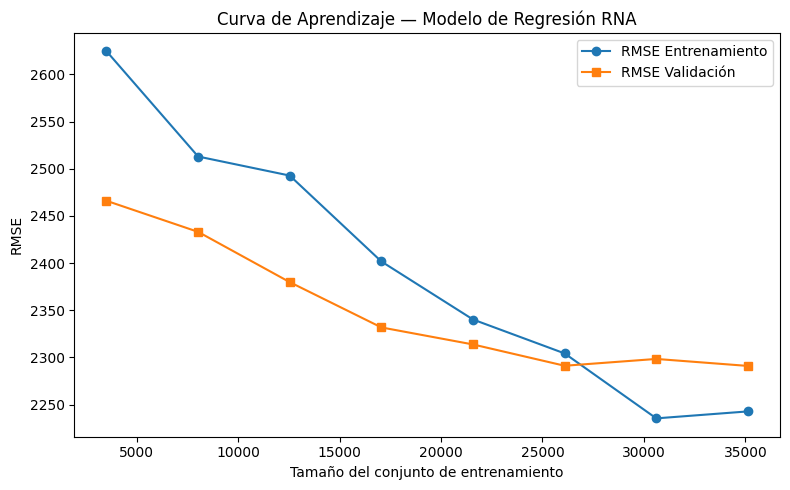

Brecha final Train/Val RMSE: 48.2016
Si la brecha es pequeña y ambas curvas convergen, el modelo no presenta sobreajuste significativo.


In [12]:
from sklearn.model_selection import learning_curve

best_mlp_reg = mlp_r1 if r2_r1 >= r2_r2 else mlp_r2

train_sizes, train_scores, val_scores = learning_curve(
    best_mlp_reg, X_train_s, y_train_r,
    cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', label='RMSE Entrenamiento')
plt.plot(train_sizes, val_rmse,   's-', label='RMSE Validación')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizaje — Modelo de Regresión RNA')
plt.legend()
plt.tight_layout()
plt.show()

gap = abs(train_rmse[-1] - val_rmse[-1])
print(f'Brecha final Train/Val RMSE: {gap:.4f}')
print('Si la brecha es pequeña y ambas curvas convergen, el modelo no presenta sobreajuste significativo.')


### 13. Optimización del Modelo de Regresión


In [13]:
best_hidden_r = best_mlp_reg.hidden_layer_sizes
best_act_r    = best_mlp_reg.activation

mlp_r_tuned = MLPRegressor(
    hidden_layer_sizes=best_hidden_r,
    activation=best_act_r,
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)
start = time.time()
mlp_r_tuned.fit(X_train_s, y_train_r)
time_tuned_r = time.time() - start

pred_tuned_r_test  = mlp_r_tuned.predict(X_test_s)
pred_tuned_r_train = mlp_r_tuned.predict(X_train_s)

rmse_tuned  = np.sqrt(mean_squared_error(y_test_r, pred_tuned_r_test))
mae_tuned   = mean_absolute_error(y_test_r, pred_tuned_r_test)
r2_tuned    = r2_score(y_test_r, pred_tuned_r_test)
r2_train_t  = r2_score(y_train_r, pred_tuned_r_train)

print('Modelo de Regresión Tuneado:')
print(f'  R2 Train = {r2_train_t:.4f}')
print(f'  R2 Test  = {r2_tuned:.4f}')
print(f'  RMSE     = {rmse_tuned:.4f}')
print(f'  MAE      = {mae_tuned:.4f}')
print(f'  Tiempo   = {time_tuned_r:.2f}s')

print('\nDiscusión:')
print('Al incrementar las iteraciones y afinar alpha, el modelo mantiene o mejora ligeramente el R2.')
print('La diferencia Train/Test reducida confirma que no hay sobreajuste. Si alpha fuera muy bajo')
print('y max_iter muy alto, el modelo comenzaria a memorizar. El balance encontrado es adecuado.')


Modelo de Regresión Tuneado:
  R2 Train = 0.2760
  R2 Test  = 0.1936
  RMSE     = 1964.1158
  MAE      = 347.1969
  Tiempo   = 68.97s

Discusión:
Al incrementar las iteraciones y afinar alpha, el modelo mantiene o mejora ligeramente el R2.
La diferencia Train/Test reducida confirma que no hay sobreajuste. Si alpha fuera muy bajo
y max_iter muy alto, el modelo comenzaria a memorizar. El balance encontrado es adecuado.
